In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import export_text

from sklearn.ensemble import RandomForestRegressor

Dataset

In [50]:
fe_csv = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
fe_df = pd.read_csv(fe_csv)

Preparing the dataset\
Preparation:

Fill missing values with zeros.\
Do train/validation/test split with 60%/20%/20% distribution.\
Use the train_test_split function and set the random_state parameter to 1.\
Use DictVectorizer(sparse=True) to turn the dataframes into matrices.

In [51]:
missing_columns = fe_df.columns[fe_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:['num_cylinders' 'horsepower' 'acceleration' 'num_doors']


In [52]:
fe_df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [53]:
def fill_numerical(df, column):
    return df[column].fillna(value=0.0)

In [54]:
for column_missing in missing_columns:
    fe_df[column_missing] = fill_numerical(fe_df, column_missing)

In [55]:
missing_columns = fe_df.columns[fe_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:[]


In [56]:
fe_df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,0.0,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,0.0,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [57]:
train_f, test = train_test_split(fe_df, test_size=0.2, random_state=1)
train, vldtn = train_test_split(train_f, test_size=0.25, random_state=1)
print(f"train: {len(train)}")
print(f"validation: {len(vldtn)}")
print(f"test: {len(test)}")

train: 5822
validation: 1941
test: 1941


In [58]:
train = train.reset_index(drop=True)
vldtn = vldtn.reset_index(drop=True)
test = test.reset_index(drop=True)

y_train = train.fuel_efficiency_mpg.values
y_vldtn = vldtn.fuel_efficiency_mpg.values
y_test = test.fuel_efficiency_mpg.values

target = "fuel_efficiency_mpg"
del train[target]
del vldtn[target]
del test[target]

In [59]:
dct_vctrzr = DictVectorizer(sparse=True)

orient = "records"
train_dct = train.to_dict(orient=orient)
vldtn_dct = vldtn.to_dict(orient=orient)
test_dct = test.to_dict(orient=orient)

X_train = dct_vctrzr.fit_transform(train_dct)

Question 1\
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

Train a model with max_depth=1.\
Which feature is used for splitting the data?

In [60]:
dcsn_tr_rgrsr = DecisionTreeRegressor(max_depth=1)
dcsn_tr_rgrsr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [61]:
print(export_text(
        dcsn_tr_rgrsr, 
        feature_names=list(dct_vctrzr.get_feature_names_out())
    )
)

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



Feature used to split data is: vehicle_weight

Question 2\
Train a random forest regressor with these parameters:

n_estimators=10\
random_state=1\
n_jobs=-1 (optional - to make training faster)\
What's the RMSE of this model on the validation data?

In [62]:
n = 10
jobs = 2
rndm_frst_rgrsr = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=jobs)
rndm_frst_rgrsr.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
X_vldtn = dct_vctrzr.transform(vldtn_dct)

In [64]:
y_prdct = rndm_frst_rgrsr.predict(X_vldtn)

In [65]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [66]:
print(f"RMSE on validation data is: {rmse(y_vldtn, y_prdct)}")

RMSE on validation data is: 0.4595777223092726


Question 3\
Now let's experiment with the n_estimators parameter

Try different values of this parameter from 10 to 200 with step 10.\
Set random_state to 1.\
Evaluate the model on the validation dataset.\
After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.

In [67]:
states = np.linspace(10, 200, 20, dtype=int)
states

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])

In [68]:
jobs = 4
rmse_scores = {}
states = np.linspace(10, 200, 20, dtype=int)
for state in states:
    rndm_frst_rgrsr = RandomForestRegressor(
        n_estimators=state, 
        random_state=1, 
        n_jobs=jobs
    )
    rndm_frst_rgrsr.fit(X_train, y_train)
    y_prdct = rndm_frst_rgrsr.predict(X_vldtn)
    rmse_scores[state] = np.round(rmse(y_vldtn, y_prdct), 3)

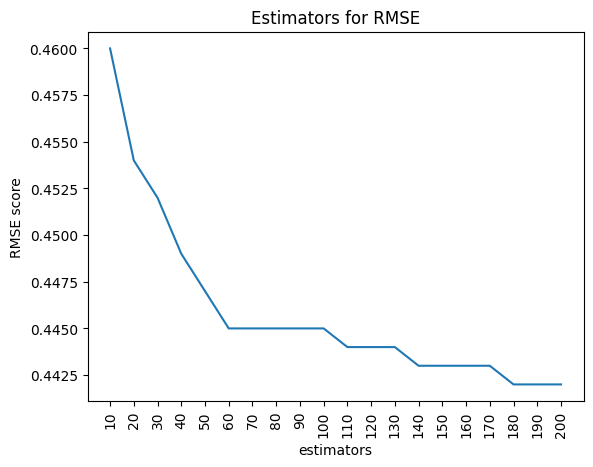

In [69]:
plt.plot(rmse_scores.keys(), rmse_scores.values())
plt.title("Estimators for RMSE")
plt.xlabel("estimators")
plt.ylabel("RMSE score")
plt.xticks(states)
plt.xticks(rotation=90)
plt.show()

RMSE stops improving at 180 estimators

Question 4\
Let's select the best max_depth:

Try different values of max_depth: [10, 15, 20, 25]\
For each of these values,
try different values of n_estimators from 10 till 200 (with step 10)
calculate the mean RMSE
Fix the random seed: random_state=1\
What's the best max_depth, using the mean RMSE?

In [70]:
states = np.linspace(10, 200, 20, dtype=int)
states

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])

In [71]:
jobs = -1
rmse_scores = {}
depths = [10, 15, 20, 25]
for depth in depths:
    for state in states:
        rndm_frst_rgrsr = RandomForestRegressor(
            n_estimators=state,
            max_depth=depth, 
            random_state=1, 
            n_jobs=jobs
        )
        rndm_frst_rgrsr.fit(X_train, y_train)
        y_prdct = rndm_frst_rgrsr.predict(X_vldtn)
        rmse_scores[(depth, state)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [72]:
rmse_scores.keys()

dict_keys([(10, np.int64(10)), (10, np.int64(20)), (10, np.int64(30)), (10, np.int64(40)), (10, np.int64(50)), (10, np.int64(60)), (10, np.int64(70)), (10, np.int64(80)), (10, np.int64(90)), (10, np.int64(100)), (10, np.int64(110)), (10, np.int64(120)), (10, np.int64(130)), (10, np.int64(140)), (10, np.int64(150)), (10, np.int64(160)), (10, np.int64(170)), (10, np.int64(180)), (10, np.int64(190)), (10, np.int64(200)), (15, np.int64(10)), (15, np.int64(20)), (15, np.int64(30)), (15, np.int64(40)), (15, np.int64(50)), (15, np.int64(60)), (15, np.int64(70)), (15, np.int64(80)), (15, np.int64(90)), (15, np.int64(100)), (15, np.int64(110)), (15, np.int64(120)), (15, np.int64(130)), (15, np.int64(140)), (15, np.int64(150)), (15, np.int64(160)), (15, np.int64(170)), (15, np.int64(180)), (15, np.int64(190)), (15, np.int64(200)), (20, np.int64(10)), (20, np.int64(20)), (20, np.int64(30)), (20, np.int64(40)), (20, np.int64(50)), (20, np.int64(60)), (20, np.int64(70)), (20, np.int64(80)), (20, np

In [73]:
best_depth = min(rmse_scores, key=rmse_scores.get)
print(f"max_depth and estimator: {best_depth} lead to best RMSE score: {rmse_scores.get(best_depth)}")

max_depth and estimator: (10, np.int64(140)) lead to best RMSE score: 0.44


Question 5\
We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.

For this homework question, we'll find the most important feature:

Train the model with these parameters:\
n_estimators=10,\
max_depth=20,\
random_state=1,\
n_jobs=-1 (optional)\
Get the feature importance information from this model\
What's the most important feature (among these 4)?

In [74]:
n = 10
depth = 20
state = 1
jobs = 2
rndm_frst_rgrsr = RandomForestRegressor(
    n_estimators=n, 
    random_state=state,
    max_depth=depth,
    n_jobs=jobs
)
rndm_frst_rgrsr.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
feature_names = dct_vctrzr.get_feature_names_out()
feature_importance = rndm_frst_rgrsr.feature_importances_

In [76]:
feature_importances = dict(zip(feature_names, feature_importance))
feature_importances = sorted(feature_importances.items(), reverse=True, key=lambda tup: tup)

In [77]:
print(f"Most important feature is: {feature_importances[0][0]} with a gain of: {feature_importances[0][1]}")

Most important feature is: vehicle_weight with a gain of: 0.9591499647407432


Question 6\
Now let's train an XGBoost model! For this question, we'll tune the eta parameter:

Install XGBoost\
Create DMatrix for train and validation\
Create a watchlist\
Train a model with these parameters for 100 rounds:

xgb_params = {\
    'eta': 0.3, \
    'max_depth': 6, \
    'min_child_weight': 1, \
    'objective': 'reg:squarederror', \
    'nthread': 8, \
    'seed': 1, \
    'verbosity': 1 \
}

In [78]:
X_train = dct_vctrzr.fit_transform(train_dct)
X_vldtn = dct_vctrzr.transform(vldtn_dct)

In [79]:
feature_names = list(feature_names)
dmtrx_train = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dmtrx_vldtn = xgb.DMatrix(X_vldtn, label=y_vldtn, feature_names=feature_names)

In [80]:
watchlist = [(dmtrx_train, "train"), (dmtrx_vldtn, "vldtn")]

In [81]:
xgb_params = {
    "eta": 0.3,
    "max_depth": 6,
    "min_child_weight": 1,
    "objective": "reg:squarederror",
    "nthread": 8,
    "seed": 1,
    "verbosity": 1,
    "eval_metric": "rmse"
}

In [82]:
%%capture output

rounds=100

xgb_mdl = xgb.train(
    xgb_params,
    dmtrx_train,
    num_boost_round=rounds,
    verbose_eval=1,
    evals=watchlist
)

In [83]:
y_prdct = xgb_mdl.predict(dmtrx_vldtn)

In [84]:
eta_rmse_score = {}

In [85]:
eta_rmse_score[xgb_params.get("eta")] = rmse(y_vldtn, y_prdct)
print(f"RMSE for eta: {xgb_params.get('eta')} is: {eta_rmse_score[xgb_params.get('eta')]}")

RMSE for eta: 0.3 is: 0.45017755678087246


In [86]:
out = output.stdout
for line in output.stdout.strip().split("\n"):
    print(line)

[0]	train-rmse:1.81393	vldtn-rmse:1.85444
[1]	train-rmse:1.31919	vldtn-rmse:1.35353
[2]	train-rmse:0.98120	vldtn-rmse:1.01316
[3]	train-rmse:0.75443	vldtn-rmse:0.78667
[4]	train-rmse:0.60680	vldtn-rmse:0.64318
[5]	train-rmse:0.51381	vldtn-rmse:0.55664
[6]	train-rmse:0.45470	vldtn-rmse:0.50321
[7]	train-rmse:0.41881	vldtn-rmse:0.47254
[8]	train-rmse:0.39534	vldtn-rmse:0.45509
[9]	train-rmse:0.38038	vldtn-rmse:0.44564
[10]	train-rmse:0.37115	vldtn-rmse:0.43896
[11]	train-rmse:0.36361	vldtn-rmse:0.43594
[12]	train-rmse:0.35850	vldtn-rmse:0.43558
[13]	train-rmse:0.35365	vldtn-rmse:0.43394
[14]	train-rmse:0.35025	vldtn-rmse:0.43349
[15]	train-rmse:0.34666	vldtn-rmse:0.43362
[16]	train-rmse:0.34459	vldtn-rmse:0.43378
[17]	train-rmse:0.34128	vldtn-rmse:0.43405
[18]	train-rmse:0.33822	vldtn-rmse:0.43391
[19]	train-rmse:0.33709	vldtn-rmse:0.43374
[20]	train-rmse:0.33553	vldtn-rmse:0.43376
[21]	train-rmse:0.33243	vldtn-rmse:0.43453
[22]	train-rmse:0.33031	vldtn-rmse:0.43510
[23]	train-rmse:0.328

In [87]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split("\n"):
        iter_line, train_line, val_line = line.split("\t")

        itrtn = int(iter_line.strip("[]"))
        train = float(train_line.split(":")[1])
        val = float(val_line.split(":")[1])

        results.append((itrtn, train, val))
    
    columns = ["num_itrtn", "trn_rmse", "vldtn_rmse"]
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [88]:
df_score_xgb = parse_xgb_output(output)

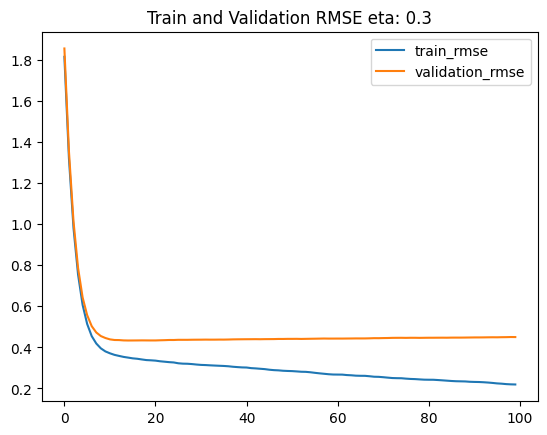

In [89]:
plt.plot(df_score_xgb.num_itrtn, df_score_xgb.trn_rmse, label="train_rmse")
plt.plot(df_score_xgb.num_itrtn, df_score_xgb.vldtn_rmse, label="validation_rmse")
plt.legend()
plt.title(f"Train and Validation RMSE eta: {xgb_params.get('eta')}")
plt.show()

Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

In [90]:
xgb_params["eta"] = 0.1

xgb_params

{'eta': 0.1,
 'max_depth': 6,
 'min_child_weight': 1,
 'objective': 'reg:squarederror',
 'nthread': 8,
 'seed': 1,
 'verbosity': 1,
 'eval_metric': 'rmse'}

In [91]:
%%capture output

xgb_mdl = xgb.train(
    xgb_params,
    dmtrx_train,
    num_boost_round=rounds,
    verbose_eval=1,
    evals=watchlist
)

In [92]:
y_prdct = xgb_mdl.predict(dmtrx_vldtn)

In [93]:
eta_rmse_score[xgb_params.get("eta")] = rmse(y_vldtn, y_prdct)
print(f"RMSE for eta: {xgb_params.get('eta')} is: {eta_rmse_score[xgb_params.get('eta')]}")

RMSE for eta: 0.1 is: 0.42622800553359225


In [94]:
best_eta = min(eta_rmse_score, key=eta_rmse_score.get)
print(f"eta: {best_eta} leads to best RMSE score: {eta_rmse_score.get(best_eta)}")

eta: 0.1 leads to best RMSE score: 0.42622800553359225


In [95]:
df_score_xgb = parse_xgb_output(output)

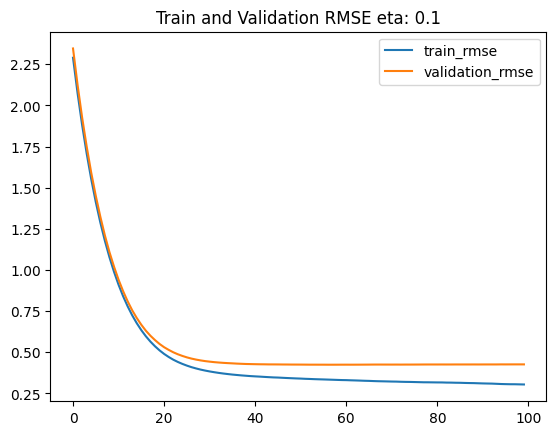

In [96]:
plt.plot(df_score_xgb.num_itrtn, df_score_xgb.trn_rmse, label="train_rmse")
plt.plot(df_score_xgb.num_itrtn, df_score_xgb.vldtn_rmse, label="validation_rmse")
plt.legend()
plt.title(f"Train and Validation RMSE eta: {xgb_params.get('eta')}")
plt.show()